<a href="https://colab.research.google.com/github/bberrium/Picsart-Academy/blob/main/Phase%203/DL/notebooks/Neural%20Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Session: From Math to PyTorch

Welcome to Phase 3. Today, we bridge the gap between theoretical calculus and modern Deep Learning.

We will start with a matrix differentiation refresher, then build a Neural Network from absolute scratch using raw NumPy to truly understand backpropagation, and finally graduate to the industry standard: **PyTorch**.

---
## Part 1: Differentiation Seminar (Math Refresher)
Before we code, let's review the calculus that powers Neural Networks.

Consider a function $ y = f(x) $ and we want to find its derivative.
- Let $ f : \mathbb{R} \rightarrow \mathbb{R} $, everyone knows what to do.
- Let $ f : \mathbb{R}^n \rightarrow \mathbb{R} $.
Now $x$ is a vector $ [x_1, x_2, \dots x_n] $. The gradient is defined as a vector of partial derivatives:
$$ \frac{df}{dx} = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n} \right] $$

- Let $ \mathbf{f} : \mathbb{R}^n \rightarrow \mathbb{R}^m $.
Now $x$ is a vector $ [x_1, \dots x_n] $ *and* $y$ is a vector $ [y_1, \dots y_m] $. The derivative is expressed by the **Jacobian matrix**:
$$ \frac{d\mathbf f}{d\mathbf x} = \begin{bmatrix} \dfrac{\partial f_1}{\partial x_1} & \cdots & \dfrac{\partial f_1}{\partial x_n}\\ \vdots & \ddots & \vdots\\ \dfrac{\partial f_m}{\partial x_1} & \cdots & \dfrac{\partial f_m}{\partial x_n} \end{bmatrix} $$

### Chain Rule
Let $ L(x) = g(f(x)) $. We aim to find $\nabla_x L$. It is the sum of 1-dimensional chains:
$$ \frac{\partial L}{\partial x_i} = \sum_{j = 1}^m \frac{\partial g}{\partial f_j} \frac{\partial f_j}{\partial x_i}. $$

### Essential Matrix Derivatives Cheat Sheet
**Ex. 1:** $y = a^T x \implies \frac{\partial y}{\partial x} = a^T$

**Ex. 2:** $y = Ax \implies \frac{dy}{dx} = A$

**Ex. 3:** $F = AS \implies \frac{dF}{dS} = ?$ (Block-diagonal matrix! Think about how the columns interact).

**Ex. 4 (Linear Regression):**
$L = || Ax - y ||_2^2$. Let $f = Ax$. Using the chain rule:
$$L = (f-y)^T(f-y) = f^Tf - 2f^Ty + y^Ty$$
$$ \frac{dL}{df} = 2(f-y)^T $$
Then, $\frac{dL}{dA} = \frac{dL}{df} \cdot \frac{df}{dA} = 2(Ax - y)x^T$ (Notice the transpose to get the dimensions to match $A$!)

---
## Part 2: The Limits of Linearity (Logic Gates)
We start with the building block: The Perceptron. A single neuron can solve linearly separable problems.
Let's try to simulate logic gates (AND, OR, XOR).

/tmp/ipykernel_1821/3351087810.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


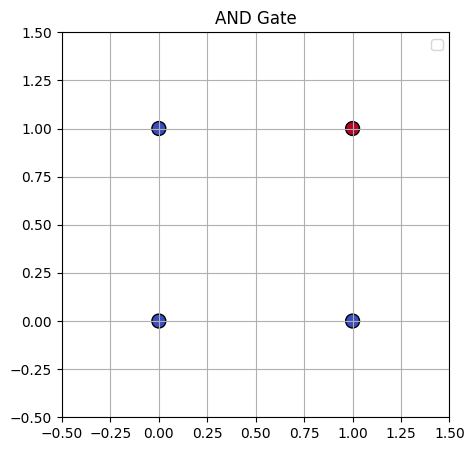

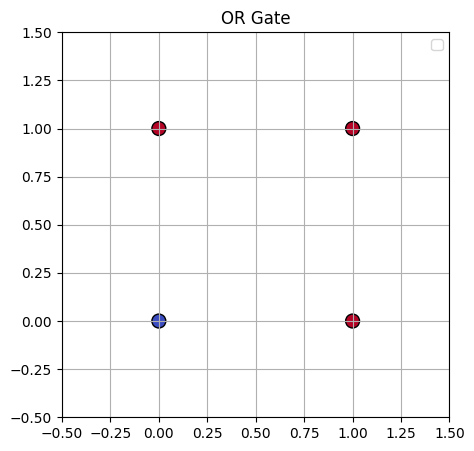

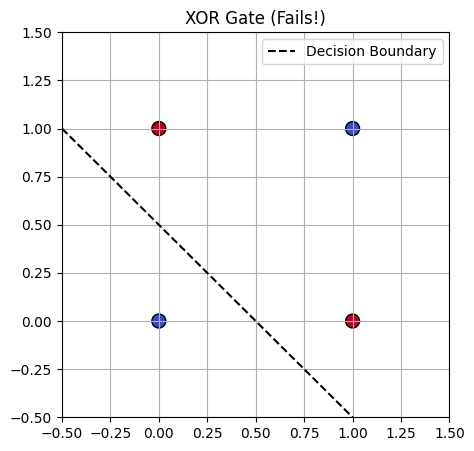

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- HELPER: Decision Boundary Visualizer ---
def visualize(X, y, w, b, title):
    plt.figure(figsize=(5,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=100, edgecolors='k')

    # Plot the line: w1*x1 + w2*x2 + b = 0  => x2 = -(w1*x1 + b) / w2
    x_min, x_max = -0.5, 1.5
    x_range = np.linspace(x_min, x_max, 100)
    if w[1] != 0:
        y_range = -(w[0]*x_range + b) / w[1]
        plt.plot(x_range, y_range, 'k--', label='Decision Boundary')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- DATA: Logic Gates ---
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

# TODO 1: Find weights (w) and bias (b) manually that solve AND.
w_and = np.array([0.0, 0.0]) # Change these!
b_and = 0.0                  # Change this!
visualize(X, y_and, w_and, b_and, "AND Gate")

# TODO 2: Find weights (w) and bias (b) manually that solve OR.
w_or = np.array([0.0, 0.0]) # Change these!
b_or = 0.0                  # Change this!
visualize(X, y_or, w_or, b_or, "OR Gate")

# TODO 3: The Failure of XOR.
# Try to find weights... (Spoiler: You can't. It is fundamentally impossible for a straight line).
w_xor = np.array([1.0, 1.0])
b_xor = -0.5
visualize(X, y_xor, w_xor, b_xor, "XOR Gate (Fails!)")

---
## Part 3: Neural Net from Scratch (The "Hard" Way)
To solve XOR, we need to bend space. We do this by adding a "Hidden Layer".

We will write a 2-layer Neural Network purely in NumPy to solve XOR.
**Goal:** Understand Backpropagation by writing the calculus explicitly. If you can do this, PyTorch will feel like magic.

In [6]:
# Input (2) -> Hidden (4) -> Output (1)
input_size, hidden_size, output_size = 2, 4, 1
learning_rate = 0.5

# Initialize Weights (Random normal) and Biases (Zeros)
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a) # Note: 'a' is the already-activated output

losses = []
y_xor_reshaped = y_xor.reshape(-1, 1)

for epoch in range(5000):
    # --- 1. FORWARD PASS ---
    # TODO: Calculate Z1 (Linear) and A1 (Activation)
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    # TODO: Calculate Z2 (Linear) and A2 (Activation)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # Loss: Mean Squared Error
    if A2 is not None:
        loss = np.mean(0.5 * (A2 - y_xor_reshaped)**2)
        losses.append(loss)

    # --- 2. BACKWARD PASS (The Chain Rule!) ---
    if A2 is not None:
        # TODO: Calculate the error at the output layer (dLoss/dZ2)
        dZ2 = (A2 - y_xor_reshaped) * sigmoid_derivative(A2)

        # TODO: Calculate gradients for W2 and b2 (Watch your matrix shapes!)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # TODO: Propagate error to the hidden layer (dLoss/dZ1)
        dZ1 = dZ2 @ W2.T * sigmoid_derivative(A1)

        # TODO: Calculate gradients for W1 and b1
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # --- 3. UPDATE WEIGHTS (SGD) ---
        if dW1 is not None:
            W1 -= learning_rate * dW1
            b1 -= learning_rate * db1
            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2

    if epoch % 1000 == 0 and A2 is not None:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

if A2 is not None:
    print("\nFinal Predictions for XOR:")
    print(np.round(A2, 3))

Epoch 0, Loss: 0.1416
Epoch 1000, Loss: 0.0106
Epoch 2000, Loss: 0.0014
Epoch 3000, Loss: 0.0006
Epoch 4000, Loss: 0.0004

Final Predictions for XOR:
[[0.016]
 [0.979]
 [0.975]
 [0.028]]


---
## Part 4: The "Easy" Way (PyTorch)
Writing backprop manually is crucial for your understanding, but prone to errors. PyTorch handles the gradient calculation for us using a dynamic computation graph called **Autograd**.

Let's solve XOR again, the modern way.

In [7]:
!pip install torch

In [8]:
import torch
import torch.nn as nn

# Convert numpy data to Tensor
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y_xor).float().view(-1, 1)

# Define Model using Sequential (LEGO blocks)
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.Sigmoid(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

# Training Loop
for epoch in range(5000):
    # 1. Forward pass
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)

    # 2. Backward pass
    optimizer.zero_grad() # Clear old gradients from the graph
    loss.backward()       # MAGIC: PyTorch calculates all gradients automatically
    optimizer.step()      # Update weights

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print("\nPyTorch Final Predictions:")
print(torch.round(model(X_tensor) * 1000) / 1000)

Epoch 0, Loss: 0.2586
Epoch 1000, Loss: 0.1965
Epoch 2000, Loss: 0.0189
Epoch 3000, Loss: 0.0053
Epoch 4000, Loss: 0.0028

PyTorch Final Predictions:
tensor([[0.0240],
        [0.9600],
        [0.9510],
        [0.0540]], grad_fn=<DivBackward0>)


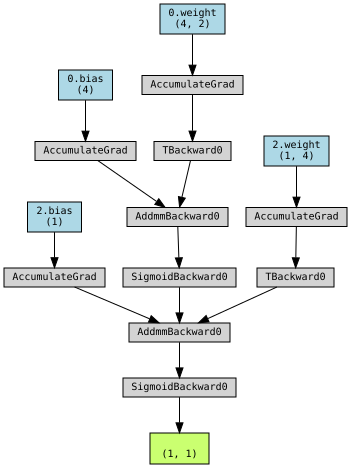

In [9]:
!pip install torchviz
# Note: It also requires the graphviz system library installed on the machine. https://graphviz.org/

from torchviz import make_dot

# 1. We need to pass a dummy input through the network to build the graph
dummy_input = torch.randn(1, 2) # 1 sample, 2 features (like x1, x2)
dummy_output = model(dummy_input)

# 2. Generate the graph
# We pass the output tensor, and the model parameters so it labels the weights (W and b)
computation_graph = make_dot(dummy_output, params=dict(model.named_parameters()))

# 3. Display it right here in the Jupyter Notebook!
computation_graph

---
## Challenge: The "Donut" Problem
XOR is tricky, but what if the data is strictly enclosed? Let's look at concentric circles (a "donut"). A linear classifier would fail completely. We need a Neural Network to essentially "draw a circle" around the inner class.

**Your Task:** Build a PyTorch model to solve this.

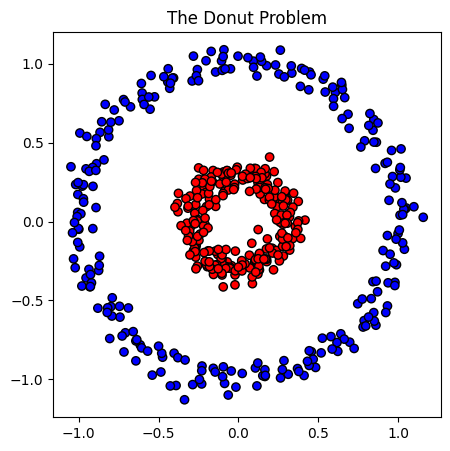

Epoch 0, Loss: 0.7159
Epoch 100, Loss: 0.0020
Epoch 200, Loss: 0.0006
Epoch 300, Loss: 0.0003
Epoch 400, Loss: 0.0002
Epoch 500, Loss: 0.0001
Epoch 600, Loss: 0.0001
Epoch 700, Loss: 0.0001
Epoch 800, Loss: 0.0000
Epoch 900, Loss: 0.0000
Training Complete!


In [10]:
from sklearn.datasets import make_circles

# 1. Generate & Visualize Data
X_np, y_np = make_circles(n_samples=500, factor=0.3, noise=0.05)
X_circ = torch.from_numpy(X_np).float()
y_circ = torch.from_numpy(y_np).float().view(-1, 1)

plt.figure(figsize=(5, 5))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='bwr', edgecolors='k')
plt.title("The Donut Problem")
plt.show()

# 2. Define Model (Hint: Try nn.Linear(2, 16) -> ReLU -> Linear(16, 16) -> ReLU -> Linear(16,1))
donut_model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

# 3. Training Setup
optimizer = torch.optim.Adam(donut_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss() # Binary Cross Entropy

# 4. Write the Training Loop (1000 epochs)
for epoch in range(1000):

  y_pred = donut_model(X_circ)
  loss = criterion(y_pred, y_circ)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


print("Training Complete!")


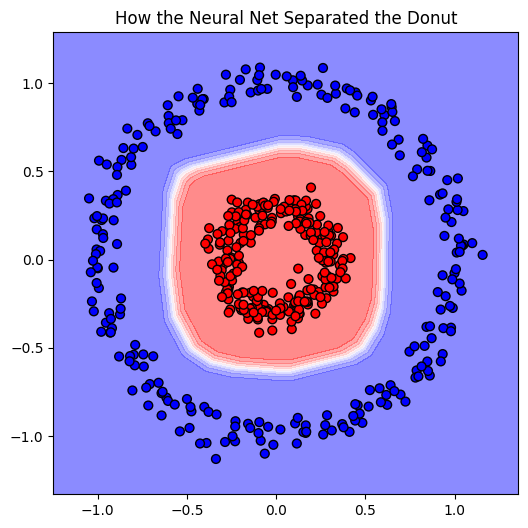

In [11]:
def plot_decision_boundary(model, X_tensor, y_tensor):
    # 1. Create a boundary grid based on data limits
    x_min, x_max = X_tensor[:, 0].min() - 0.2, X_tensor[:, 0].max() + 0.2
    y_min, y_max = X_tensor[:, 1].min() - 0.2, X_tensor[:, 1].max() + 0.2

    # Generate 500x500 points covering the entire space
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    # 2. Convert grid coordinates into a PyTorch tensor
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.from_numpy(grid_points).float()

    # 3. Get predictions without tracking gradients
    model.eval()
    with torch.no_grad():
        logits = model(grid_tensor)
        # Since we removed Sigmoid from the model, we apply it here to get 0 to 1 probabilities
        probs = torch.sigmoid(logits)

    # Reshape predictions back into the 2D grid shape
    Z = probs.view(xx.shape).numpy()

    # 4. Plot the results
    plt.figure(figsize=(6, 6))

    # Draw the filled color zones (faint red/blue background)
    plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.5, levels=np.linspace(0, 1, 11))

    # Overlay the original dataset points
    plt.scatter(X_tensor[:, 0], X_tensor[:, 1], c=y_tensor.numpy().ravel(), cmap='bwr', edgecolors='k', s=40)

    plt.title("How the Neural Net Separated the Donut")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(False)
    plt.show()

# --- CALL IT AFTER YOUR TRAINING LOOP ---
plot_decision_boundary(donut_model, X_circ, y_circ)

---
## The Hook: Moving to Images (MNIST)
So far, we have only passed 2 numbers into our neural networks ($x_1, x_2$). But the true power of Deep Learning lies in high-dimensional data, like images.

Run the cell below to load the famous **MNIST Digits Dataset**.

We have 1797 images.
Each image is a 8x8 grid of pixels.


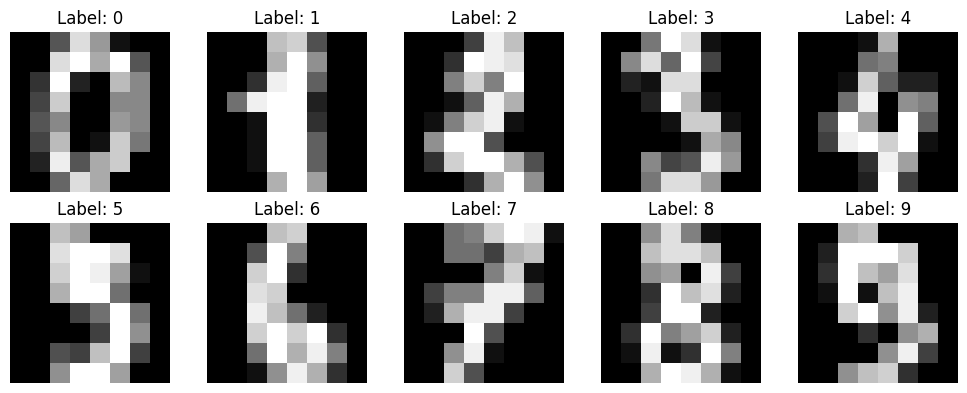

In [12]:
from sklearn.datasets import load_digits

digits = load_digits()
images = digits.images
targets = digits.target

print(f"We have {images.shape[0]} images.")
print(f"Each image is a {images.shape[1]}x{images.shape[2]} grid of pixels.")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Label: {targets[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
X_flat = images.reshape(images.shape[0], -1)
X_flat = X_flat / 16.0
y_flat = targets.reshape(-1, 1)


In [20]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# ==========================================
# 1. CUSTOM OBJECT-ORIENTED FRAMEWORK LAYERS
# ==========================================

class Linear:
    def __init__(self, in_features, out_features):
        # Initialize weights small but non-zero to break symmetry
        self.W = np.random.randn(in_features, out_features) * 0.01
        self.b = np.zeros((1, out_features))

        # # What you write:
        # Z = dot_product_matrix + self.b  # Shape: (1797, 32) + (1, 32)

        # # What NumPy secretly does behind the scenes:
        # # It replicates your single row 1,797 times downwards to create a temporary matching (1797, 32) matrix!
        # [
        #   [b_1, b_2, ..., b_32], # Replicated for Image 1
        #   [b_1, b_2, ..., b_32], # Replicated for Image 2
        #   ...
        #   [b_1, b_2, ..., b_32]  # Replicated for Image 1797
        # ]

        # Cache variables for backpropagation
        self.X = None
        self.dW = None
        self.db = None

    def forward(self, X):
        self.X = X
        return np.dot(X, self.W) + self.b

    def backward(self, dout):
        # Gradient with respect to weights, bias, and input data
        self.dW = np.dot(self.X.T, dout)
        self.db = np.sum(dout, axis=0, keepdims=True)
        return np.dot(dout, self.W.T)

#         Neuron 1    Neuron 2   ...   Neuron 32
#         +----------+----------+-----+-----------+
# Image 0 |   -0.12  |   +0.05  | ... |   -0.01   |  <- Error values for Sticky Note 0
# Image 1 |   +2.41  |   -1.10  | ... |   +0.00   |  <- Error values for Sticky Note 1
#   ...   |   ...    |   ...    | ... |    ...    |
# Every single number inside dout is a direct question-and-answer about blame:

#     "For Image 0, if Neuron 1 forces its output up by a tiny fraction, how much will the total network loss change?"
#     If a value is negative (like -0.12): It means increasing this neuron's activation will actually decrease the overall error. The network wants more of this signal!
#     If a value is positive (like +2.41): It means this neuron blundered. Increasing its activation will make the total error worse. The network wants to suppress this signal.

class ReLU:
    def __init__(self):
        self.X = None

    def forward(self, X):
        self.X = X
        return np.maximum(0, X)

    def backward(self, dout):
        # Passes gradient through only if the original input was positive
        return dout * (self.X > 0)

class SoftmaxCrossEntropy:
    def __init__(self):
        self.probs = None
        self.y = None

    def forward(self, Z, y):
        self.y = y
        # Stable Softmax numerical execution trick
        row_maxes = np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z - row_maxes)
        self.probs = exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

        # Categorical Cross-Entropy evaluation
        num_samples = Z.shape[0]
        probs_clipped = np.clip(self.probs, 1e-15, 1.0 - 1e-15)
        correct_class_probs = probs_clipped[np.arange(num_samples), y.ravel()]
        loss = -np.sum(np.log(correct_class_probs)) / num_samples
        return loss

    def backward(self):
        # Highly optimized combined derivative: (P - Y) / N
        num_samples = self.probs.shape[0]
        Y_one_hot = np.zeros_like(self.probs)
        Y_one_hot[np.arange(num_samples), self.y.ravel()] = 1.0
        return (self.probs - Y_one_hot) / num_samples

# ==========================================
# 2. DATA PREPARATION
# ==========================================

digits = load_digits()
# Flatten 8x8 matrices into 64 elements and scale to [0, 1]
X = digits.images.reshape(digits.images.shape[0], -1) / 16.0
y = digits.target.reshape(-1, 1) # Set up as a 2D column vector

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. INITIALIZE PIPELINE & TRAINING LOOP
# ==========================================

# Architecture: 64 inputs -> 32 Hidden Units (ReLU) -> 10 Output Scores
layer1 = Linear(64, 32)
activation1 = ReLU()
layer2 = Linear(32, 10)
loss_layer = SoftmaxCrossEntropy()

learning_rate = 0.5
epochs = 400

print("Training Custom NumPy Framework...")
for epoch in range(epochs + 1):
    # --- Forward Pass ---
    out1 = layer1.forward(X_train)
    act1 = activation1.forward(out1)
    out2 = layer2.forward(act1)
    loss = loss_layer.forward(out2, y_train)

    # --- Backward Pass ---
    dout2 = loss_layer.backward()
    dact1 = layer2.backward(dout2)
    dout1 = activation1.backward(dact1)
    dX    = layer1.backward(dout1)

    # --- Weight Updates (Gradient Descent) ---
    layer2.W -= learning_rate * layer2.dW
    layer2.b -= learning_rate * layer2.db
    layer1.W -= learning_rate * layer1.dW
    layer1.b -= learning_rate * layer1.db

    # Track performance metrics
    if epoch % 50 == 0:
        # Calculate accurate class predictions on training set
        train_preds = np.argmax(loss_layer.probs, axis=1).reshape(-1, 1)
        train_acc = np.mean(train_preds == y_train) * 100
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.2f}%")

# ==========================================
# 4. EVALUATION ON HIDDEN TEST SET
# ==========================================

test_out1 = layer1.forward(X_test)
test_act1 = activation1.forward(test_out1)
test_out2 = layer2.forward(test_act1)

# Run test outputs through a final evaluation to pull probabilities
loss_layer.forward(test_out2, y_test)
test_preds = np.argmax(loss_layer.probs, axis=1).reshape(-1, 1)
test_acc = np.mean(test_preds == y_test) * 100

print(f"\n[NumPy Final Result] Test Set Accuracy: {test_acc:.2f}%")

Training Custom NumPy Framework...
Epoch 000 | Loss: 2.3025 | Train Acc: 6.75%
Epoch 050 | Loss: 1.1485 | Train Acc: 76.34%
Epoch 100 | Loss: 0.3341 | Train Acc: 91.86%
Epoch 150 | Loss: 0.1979 | Train Acc: 94.85%
Epoch 200 | Loss: 0.1423 | Train Acc: 96.73%
Epoch 250 | Loss: 0.1138 | Train Acc: 97.49%
Epoch 300 | Loss: 0.0961 | Train Acc: 97.70%
Epoch 350 | Loss: 0.0837 | Train Acc: 98.26%
Epoch 400 | Loss: 0.0744 | Train Acc: 98.40%

[NumPy Final Result] Test Set Accuracy: 96.67%


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# ==========================================
# 1. DATA PREPARATION & TENSOR CONVERSION
# ==========================================

digits = load_digits()
X_np = digits.images.reshape(digits.images.shape[0], -1) / 16.0
y_np = digits.target

X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

# Convert NumPy arrays to target PyTorch tensors (inputs = float32, labels = long)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# ==========================================
# 2. DEFINE NETWORK STRUCTURE
# ==========================================

# nn.CrossEntropyLoss handles the Softmax activation internally
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

# Set up standard cross-entropy and the Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 3. TRAINING LOOP WITH AUTOMATIC GRADIENTS
# ==========================================

epochs = 400

print("Training Production PyTorch Engine...")
for epoch in range(epochs + 1):
    model.train() # Set network to training operational state

    # 1. Forward Pass
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    # 2. Backward Pass (Autograd tracking engine execution)
    optimizer.zero_grad() # Reset residual memory gradients from prior loops
    loss.backward()       # Automatically computes all layer dW and db values
    optimizer.step()      # Update network parameters

    # Track performance metrics
    if epoch % 50 == 0:
        with torch.no_grad(): # Disable gradient computational tracking for metrics
            preds = torch.argmax(logits, dim=1)
            train_acc = (preds == y_train_t).float().mean() * 100
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Train Acc: {train_acc.item():.2f}%")

# ==========================================
# 4. EVALUATION ON HIDDEN TEST SET
# ==========================================

model.eval() # Switch network out of training mode
with torch.no_grad():
    test_logits = model(X_test_t)
    test_preds = torch.argmax(test_logits, dim=1)
    test_acc = (test_preds == y_test_t).float().mean() * 100

print(f"\n[PyTorch Final Result] Test Set Accuracy: {test_acc.item():.2f}%")

Training Production PyTorch Engine...
Epoch 000 | Loss: 2.3129 | Train Acc: 11.00%
Epoch 050 | Loss: 0.1666 | Train Acc: 95.96%
Epoch 100 | Loss: 0.0628 | Train Acc: 98.54%
Epoch 150 | Loss: 0.0309 | Train Acc: 99.79%
Epoch 200 | Loss: 0.0173 | Train Acc: 99.93%
Epoch 250 | Loss: 0.0108 | Train Acc: 100.00%
Epoch 300 | Loss: 0.0074 | Train Acc: 100.00%
Epoch 350 | Loss: 0.0054 | Train Acc: 100.00%
Epoch 400 | Loss: 0.0041 | Train Acc: 100.00%

[PyTorch Final Result] Test Set Accuracy: 97.22%


### Your Homework and The Future

To feed these images into the networks we built today, we would have to flatten the 8x8 grid into a 1D vector of 64 numbers. This destroys the spatial information (an eye doesn't look like an eye anymore when it's flattened into a line).

**For your Homework:** You will build a custom object-oriented Deep Learning framework (just like PyTorch) entirely from scratch using NumPy, and you will train it to classify these digits!

**For the Next Lecture:** We will introduce a totally new mathematical operation designed specifically to keep spatial information intact without flattening the images: **Convolutional Neural Networks (CNNs)**.